# AI-Driven Development Planning and Impact Prediction Using MPLADS Data

To develop an intelligent ML-based system that analyzes MPLADS development data and predicts key project-related outcomes to support data-driven planning, resource allocation, and monitoring of local development works

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

# Dataset

In [5]:
df = pd.read_csv(r'C:\\Users\\Arjun Singh Tomar\\Downloads\\mplads_data_csv.csv') # MPLADS Dataset 

# Exploratory Data Analysis

In [6]:
df.head()

,project_id,work_name,category,mp_name,state,district,agency_name,sanction_date,expected_completion,actual_completion,...,expenditure,progress_percentage,latitude,longitude,status,is_cost_anomaly,is_exp_anomaly,is_progress_anomaly,is_delay,is_duplicate
0,MPLAD-2024-00000,Construction of Community Hall in District_1,Community Hall,MP_48,Maharashtra,District_1,Agency_9,2023-10-07,2024-04-26,NaN,...,1739533.45,62.05,12.523841,69.684425,In Progress,False,False,False,False,True
1,MPLAD-2024-00001,Construction of Roads in District_8,Roads,MP_33,Uttar Pradesh,District_8,Agency_20,2023-10-07,2024-07-20,NaN,...,4080008.07,47.58,32.140837,74.157834,In Progress,True,False,False,False,False
2,MPLAD-2024-00002,Construction of Roads in District_14,Roads,MP_22,Uttar Pradesh,District_14,Agency_9,2023-02-17,2023-11-21,2024-04-17,...,802943.03,47.35,16.445645,85.743734,Delayed,False,False,False,True,False
3,MPLAD-2024-00003,Construction of Roads in District_18,Roads,MP_8,Karnataka,District_18,Agency_13,2023-07-05,2024-05-27,NaN,...,1345244.10,50.93,13.790540,82.912799,In Progress,True,False,False,False,False
4,MPLAD-2024-00004,Construction of Community Hall in District_10,Community Hall,MP_6,Uttar Pradesh,District_10,Agency_28,2023-11-22,2024-08-21,NaN,...,1491206.67,42.32,35.517681,96.003329,In Progress,False,False,False,False,False


1 . Missing Values 

In [7]:
df.isnull().sum()

project_id                0
work_name                 0
category                  0
mp_name                   0
state                     0
district                  0
agency_name               0
sanction_date             0
expected_completion       0
actual_completion      4270
estimated_cost            0
sanctioned_amount         0
released_amount           0
expenditure               0
progress_percentage       0
latitude                  0
longitude                 0
status                    0
is_cost_anomaly           0
is_exp_anomaly            0
is_progress_anomaly       0
is_delay                  0
is_duplicate              0
dtype: int64

In [8]:
df = df.drop(columns='actual_completion',axis=1)

In [9]:
df.isnull().sum()

project_id             0
work_name              0
category               0
mp_name                0
state                  0
district               0
agency_name            0
sanction_date          0
expected_completion    0
estimated_cost         0
sanctioned_amount      0
released_amount        0
expenditure            0
progress_percentage    0
latitude               0
longitude              0
status                 0
is_cost_anomaly        0
is_exp_anomaly         0
is_progress_anomaly    0
is_delay               0
is_duplicate           0
dtype: int64

2 . Duplicated Value 

In [10]:
df.duplicated().sum() # There is no duplicate value

np.int64(0)

3 . Type of the features

In [11]:
df.dtypes

project_id              object
work_name               object
category                object
mp_name                 object
state                   object
district                object
agency_name             object
sanction_date           object
expected_completion     object
estimated_cost         float64
sanctioned_amount      float64
released_amount        float64
expenditure            float64
progress_percentage    float64
latitude               float64
longitude              float64
status                  object
is_cost_anomaly           bool
is_exp_anomaly            bool
is_progress_anomaly       bool
is_delay                  bool
is_duplicate              bool
dtype: object

4 . Check the shape of the data

In [12]:
df.shape # there are the 5000 rows and 22 columns in the dataset

(5000, 22)

5 . Information about the individual columns 

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   project_id           5000 non-null   object 
 1   work_name            5000 non-null   object 
 2   category             5000 non-null   object 
 3   mp_name              5000 non-null   object 
 4   state                5000 non-null   object 
 5   district             5000 non-null   object 
 6   agency_name          5000 non-null   object 
 7   sanction_date        5000 non-null   object 
 8   expected_completion  5000 non-null   object 
 9   estimated_cost       5000 non-null   float64
 10  sanctioned_amount    5000 non-null   float64
 11  released_amount      5000 non-null   float64
 12  expenditure          5000 non-null   float64
 13  progress_percentage  5000 non-null   float64
 14  latitude             5000 non-null   float64
 15  longitude            5000 non-null   f

6 . Statistics

In [14]:
df.describe() # Mathematical calculation of the numerical features

,estimated_cost,sanctioned_amount,released_amount,expenditure,progress_percentage,latitude,longitude
count,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5000.000000
mean,2.995754e+06,3.311700e+06,2.491829e+06,1.942739e+06,53.552118,22.347427,82.489385
std,1.149900e+06,1.633731e+06,1.336243e+06,1.231036e+06,21.745249,8.285657,8.359277
min,1.000022e+06,9.750635e+05,5.075945e+05,2.959609e+05,3.430000,8.007045,68.002830
25%,1.977612e+06,2.104002e+06,1.518150e+06,1.105622e+06,40.522500,15.167965,75.314508
50%,3.002959e+06,3.139897e+06,2.284204e+06,1.674581e+06,52.305000,22.372619,82.379523
75%,3.994806e+06,4.197690e+06,3.157227e+06,2.455185e+06,67.527500,29.469190,89.709054
max,4.998625e+06,1.185101e+07,1.151974e+07,1.459243e+07,100.000000,36.996272,96.991813


7 . Univariate Analysis (Numerical Columns)

<Axes: xlabel='estimated_cost', ylabel='Count'>

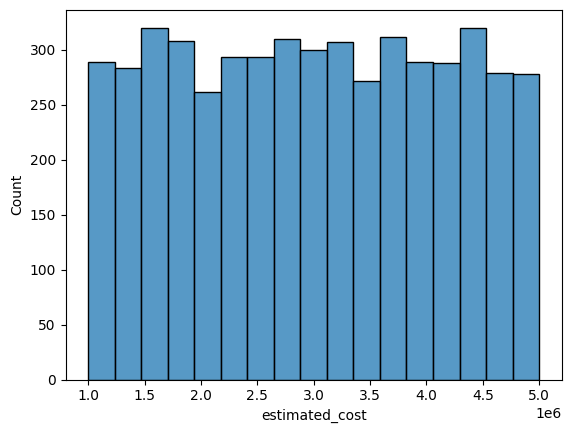

In [15]:
sns.histplot(x = 'estimated_cost',data = df)

<Axes: xlabel='sanctioned_amount', ylabel='Count'>

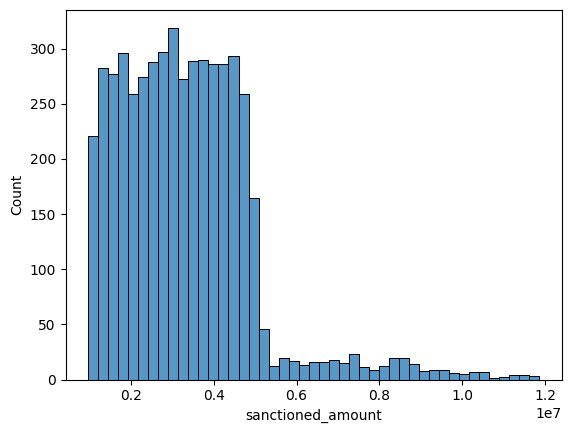

In [16]:
sns.histplot(x = 'sanctioned_amount',data=df)

<Axes: xlabel='released_amount', ylabel='Count'>

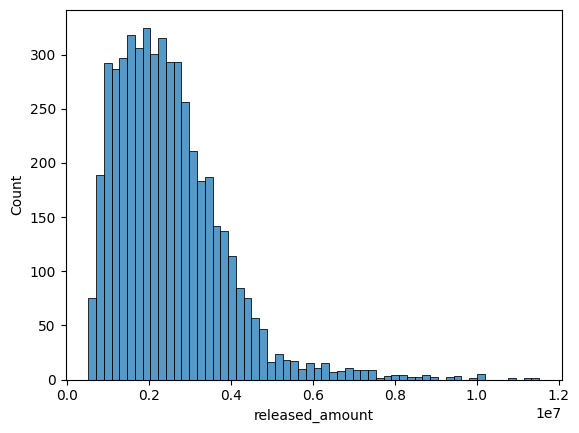

In [17]:
sns.histplot(x = 'released_amount',data = df)

<Axes: xlabel='expenditure', ylabel='Count'>

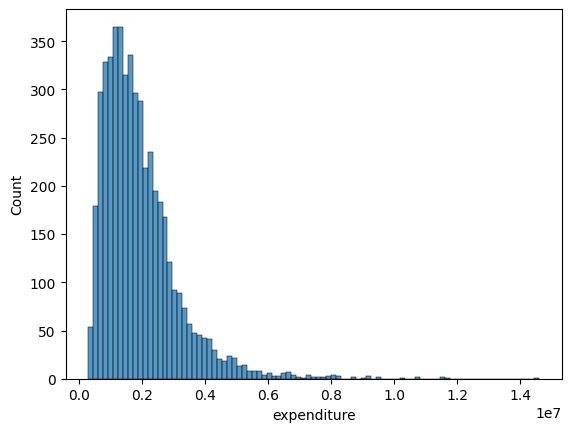

In [18]:
sns.histplot(x = 'expenditure',data = df)

<Axes: xlabel='progress_percentage', ylabel='Count'>

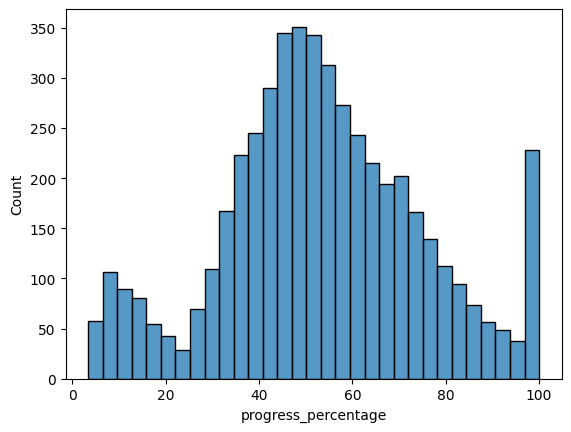

In [19]:
sns.histplot(x = 'progress_percentage',data = df)

<Axes: xlabel='latitude', ylabel='Count'>

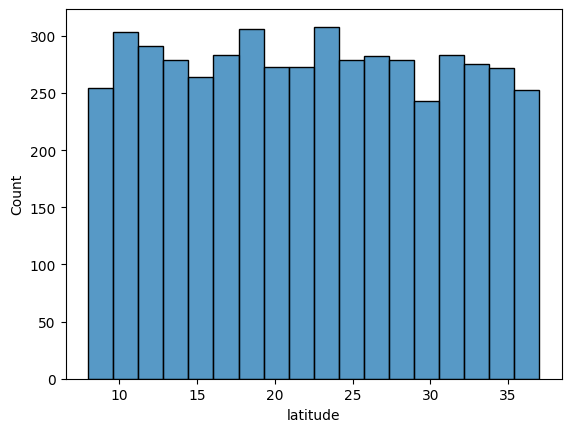

In [20]:
sns.histplot(x = 'latitude',data = df)

<Axes: xlabel='longitude', ylabel='Count'>

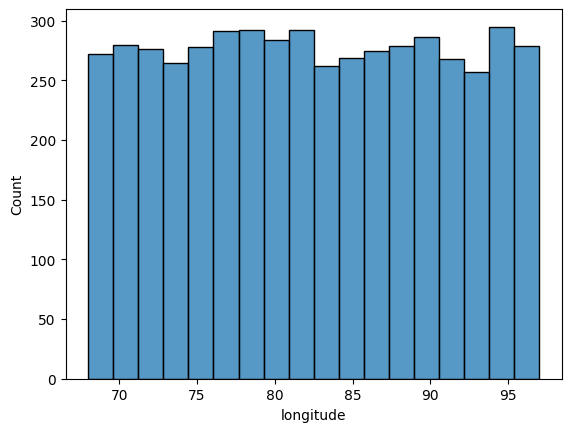

In [21]:
sns.histplot(x = 'longitude',data = df)

8 .  Univariate Analysis(Categorical Columns)

In [22]:
df['category'].value_counts()

category
Water Supply      861
Sanitation        859
Roads             832
Community Hall    825
Education         818
Health            805
Name: count, dtype: int64

<Axes: xlabel='category', ylabel='count'>

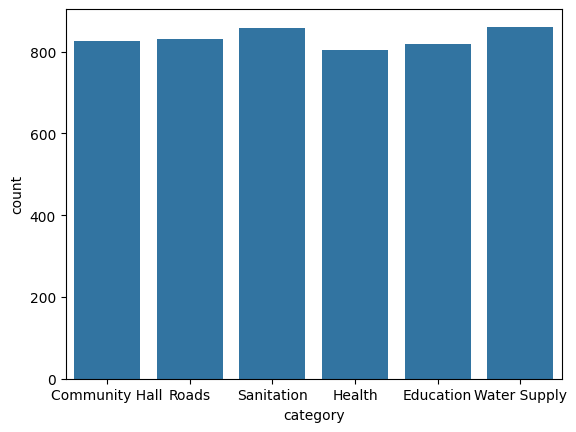

In [23]:
sns.countplot(x = 'category',data = df)

In [24]:
df['mp_name'].value_counts()

mp_name
MP_22    129
MP_7     122
MP_42    120
MP_29    120
MP_43    117
MP_10    117
MP_41    117
MP_14    115
MP_49    114
MP_21    110
MP_1     108
MP_4     108
MP_3     107
MP_17    106
MP_44    106
MP_28    106
MP_33    105
MP_26    105
MP_34    103
MP_37    103
MP_20    103
MP_8     103
MP_27    102
MP_9     101
MP_36    100
MP_23    100
MP_31    100
MP_48    100
MP_38     99
MP_18     99
MP_6      99
MP_16     99
MP_45     97
MP_25     97
MP_5      96
MP_39     96
MP_35     95
MP_2      94
MP_24     93
MP_11     93
MP_13     92
MP_12     92
MP_40     91
MP_19     90
MP_30     90
MP_15     87
MP_47     85
MP_32     85
MP_46     84
Name: count, dtype: int64

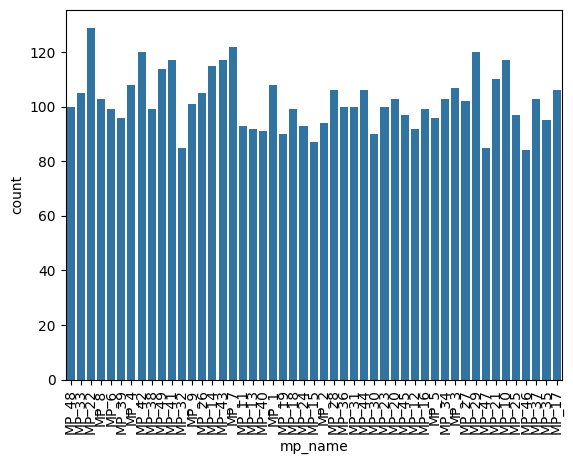

In [25]:
sns.countplot(x = 'mp_name',data = df)
plt.xticks(rotation=90)
plt.show()

In [26]:
df['state'].value_counts()

state
Karnataka        1083
Maharashtra       983
Uttar Pradesh     981
Gujarat           981
Tamil Nadu        972
Name: count, dtype: int64

<Axes: xlabel='state', ylabel='count'>

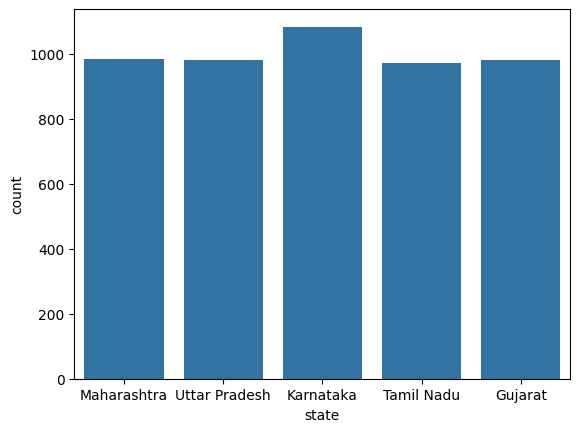

In [27]:
sns.countplot(x = 'state',data = df)

In [28]:
df['district'].value_counts()

district
District_10    297
District_1     286
District_13    284
District_8     278
District_7     274
District_3     273
District_14    271
District_17    268
District_19    268
District_4     266
District_6     263
District_18    255
District_16    254
District_5     252
District_11    251
District_2     248
District_12    238
District_15    238
District_9     236
Name: count, dtype: int64

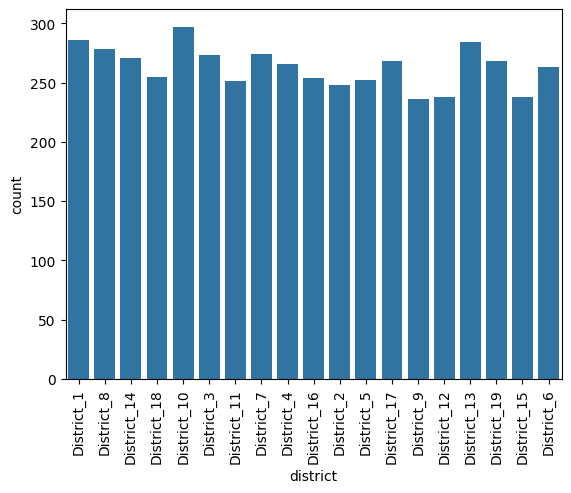

In [29]:
sns.countplot(x = 'district',data = df)
plt.xticks(rotation = 90)
plt.show()

In [30]:
df['agency_name'].value_counts()

agency_name
Agency_22    212
Agency_5     198
Agency_14    190
Agency_24    189
Agency_25    186
Agency_23    183
Agency_8     181
Agency_6     181
Agency_13    179
Agency_19    177
Agency_26    176
Agency_21    175
Agency_11    175
Agency_7     174
Agency_20    174
Agency_4     173
Agency_2     171
Agency_1     171
Agency_16    168
Agency_17    166
Agency_15    166
Agency_3     163
Agency_28    161
Agency_12    160
Agency_9     157
Agency_29    154
Agency_10    151
Agency_27    148
Agency_18    141
Name: count, dtype: int64

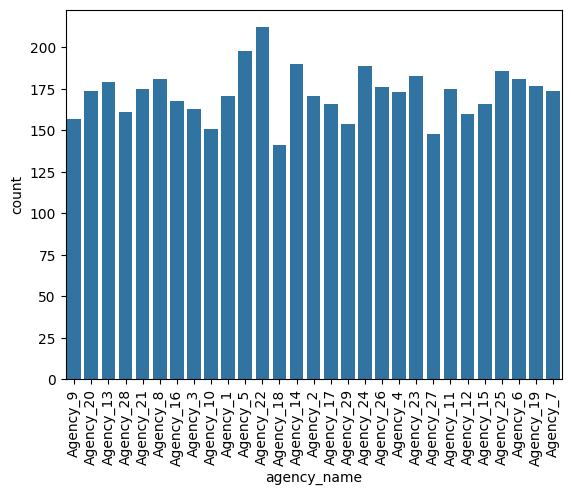

In [31]:
sns.countplot(x = 'agency_name',data = df)
plt.xticks(rotation = 90)
plt.show()

In [32]:
df['is_cost_anomaly'].value_counts()

is_cost_anomaly
False    4466
True      534
Name: count, dtype: int64

<Axes: xlabel='is_cost_anomaly', ylabel='count'>

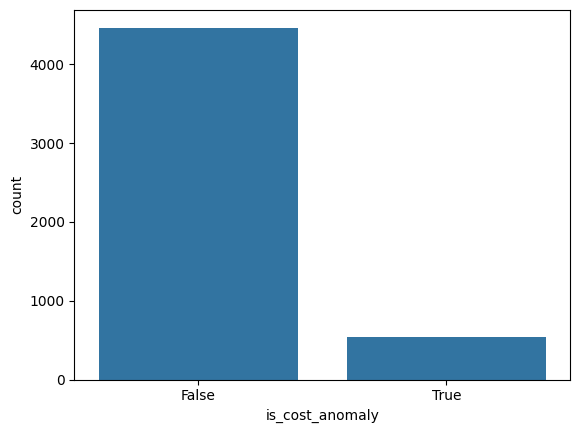

In [33]:
sns.countplot(x = 'is_cost_anomaly',data = df)

In [34]:
df['is_exp_anomaly'].value_counts()

is_exp_anomaly
False    4508
True      492
Name: count, dtype: int64

<Axes: xlabel='is_exp_anomaly', ylabel='count'>

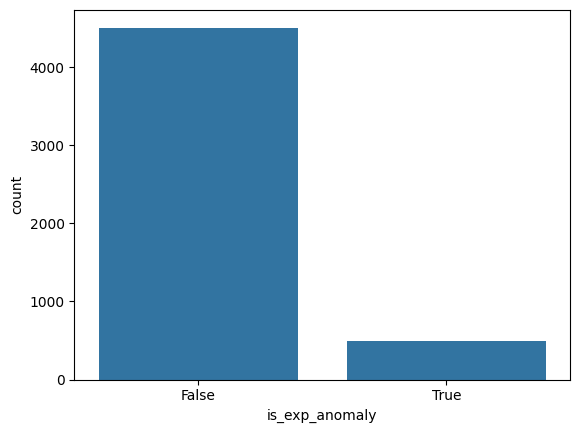

In [35]:
sns.countplot(x = 'is_exp_anomaly',data = df)

In [36]:
df['is_progress_anomaly'].value_counts()

is_progress_anomaly
False    4495
True      505
Name: count, dtype: int64

<Axes: xlabel='is_progress_anomaly', ylabel='count'>

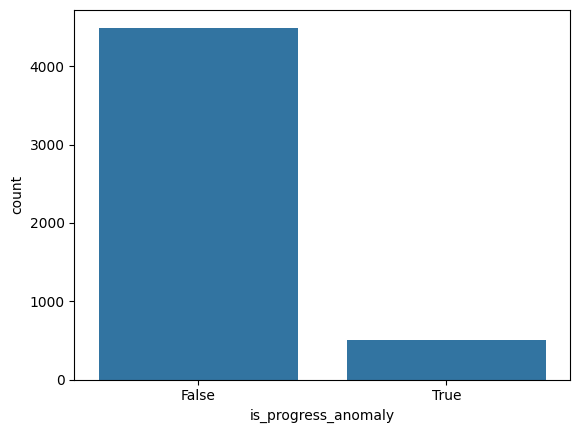

In [37]:
sns.countplot(x = 'is_progress_anomaly',data = df)

In [38]:
df['is_delay'].value_counts()

is_delay
False    4494
True      506
Name: count, dtype: int64

<Axes: xlabel='is_delay', ylabel='count'>

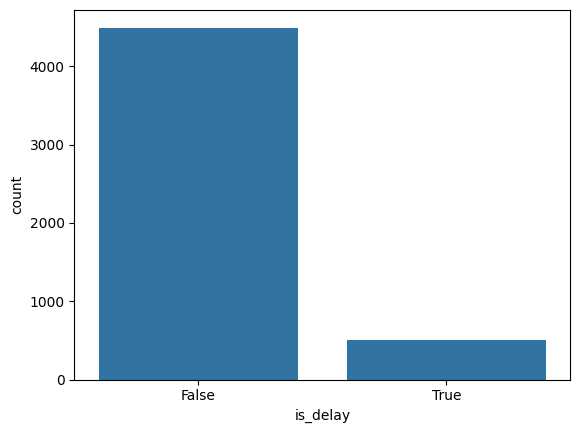

In [39]:
sns.countplot(x = 'is_delay',data = df)

In [40]:
df['is_duplicate'].value_counts()

is_duplicate
False    4777
True      223
Name: count, dtype: int64

<Axes: xlabel='is_duplicate', ylabel='count'>

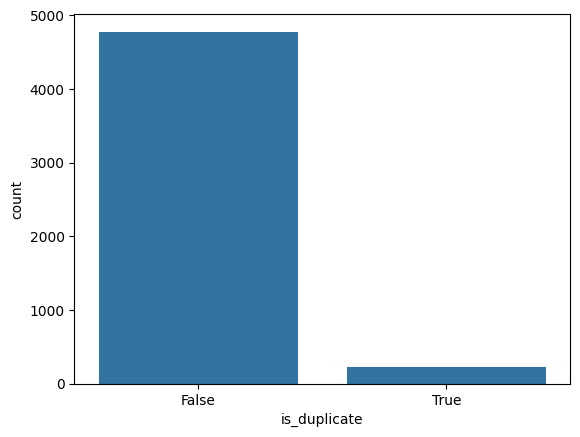

In [41]:
sns.countplot(x = 'is_duplicate',data = df)

9 . Bivariate Analysis (Numerical VS Numerical )

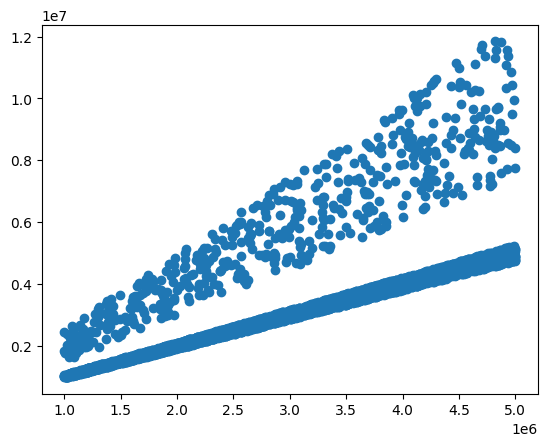

In [42]:
plt.scatter(x = 'estimated_cost',y = 'sanctioned_amount',data = df)

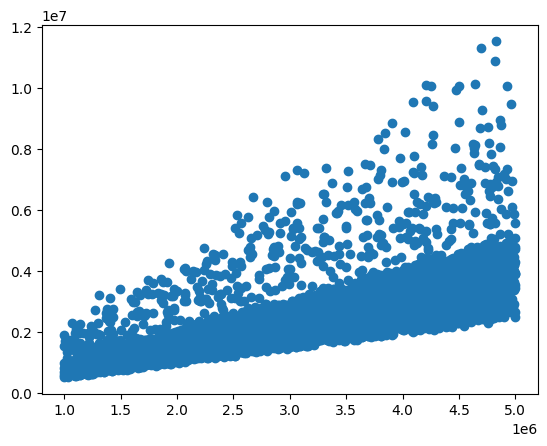

In [43]:
plt.scatter(x = 'estimated_cost',y = 'released_amount',data = df)

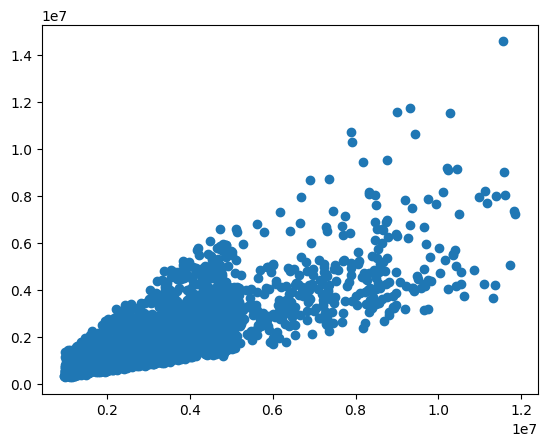

In [44]:
plt.scatter(x = 'sanctioned_amount',y = 'expenditure',data = df)

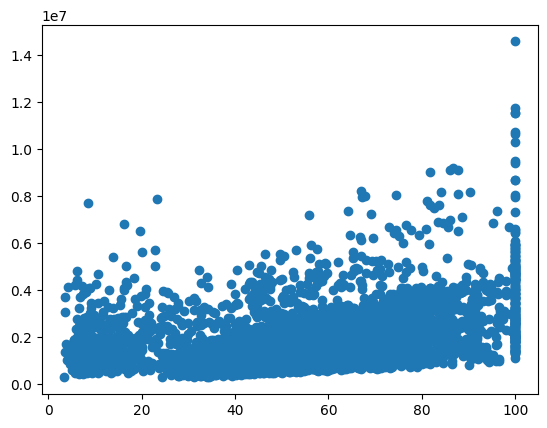

In [45]:
plt.scatter(x = 'progress_percentage',y = 'expenditure',data = df)

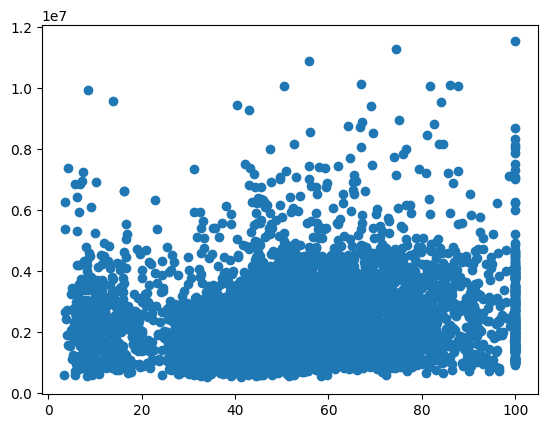

In [46]:
plt.scatter(x = 'progress_percentage',y = 'released_amount',data = df)

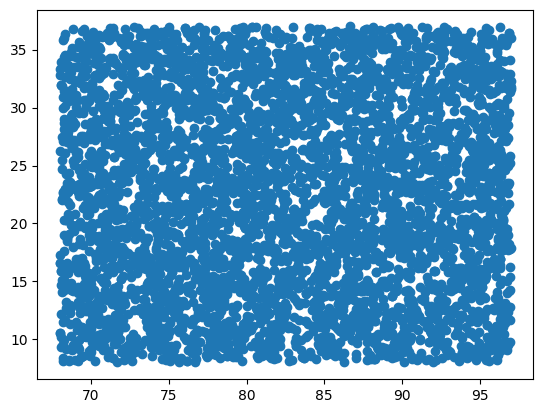

In [47]:
plt.scatter(x = 'longitude',y = 'latitude',data = df)

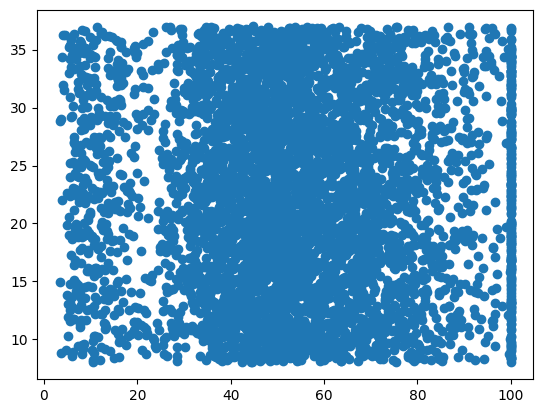

In [48]:
plt.scatter(x = 'progress_percentage',y = 'latitude',data = df)

10 . Bivariate Analysis (Categorical VS Categorical)

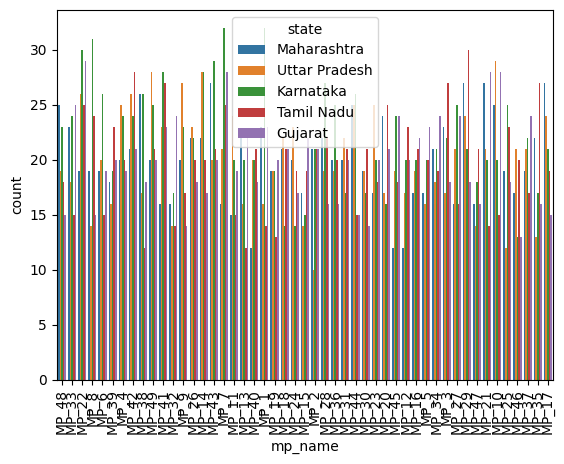

In [49]:
sns.countplot(x = 'mp_name' , hue = 'state',data = df)
plt.xticks(rotation = 90)
plt.show()

<Axes: xlabel='district', ylabel='mp_name'>

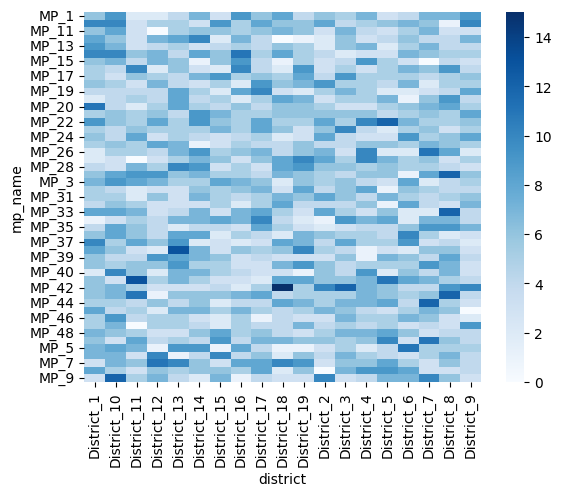

In [50]:
sns.heatmap(
    pd.crosstab(df['mp_name'], df['district']),
    cmap='Blues'
)


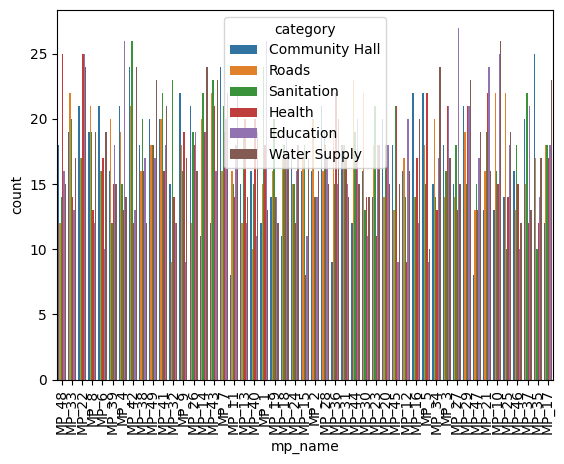

In [51]:
sns.countplot(x = 'mp_name' , hue = 'category',data = df)
plt.xticks(rotation = 90)
plt.show()

<Axes: xlabel='state', ylabel='count'>

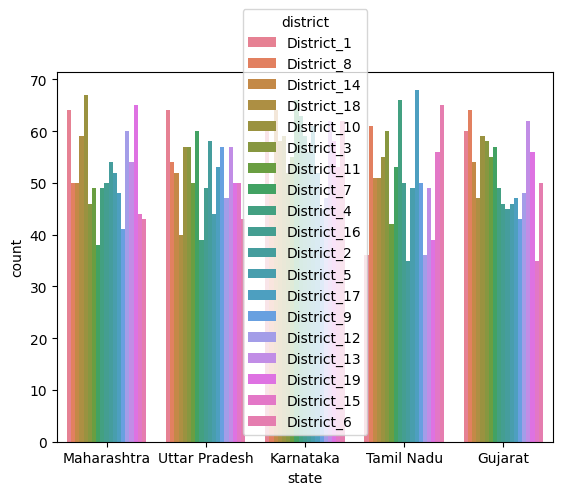

In [52]:
sns.countplot(x = 'state',hue = 'district',data = df)

<Axes: xlabel='state', ylabel='count'>

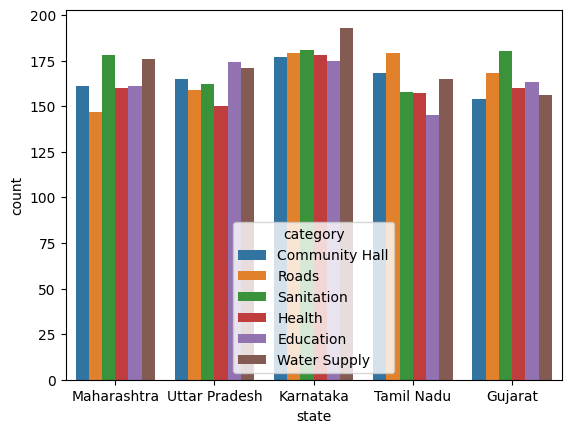

In [53]:
sns.countplot(x = 'state',hue = 'category',data = df)

<Axes: xlabel='state', ylabel='count'>

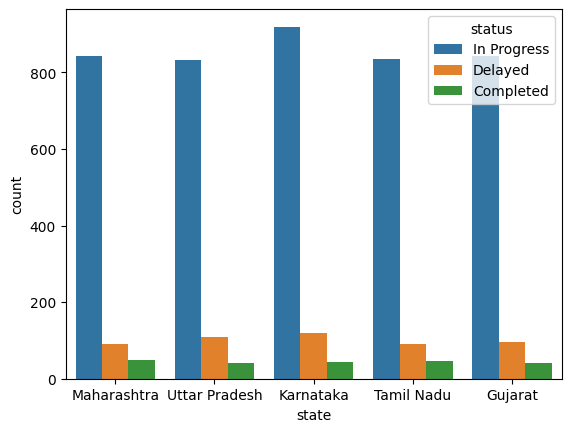

In [54]:
sns.countplot(x = 'state',hue = 'status',data = df)

<Axes: xlabel='category', ylabel='count'>

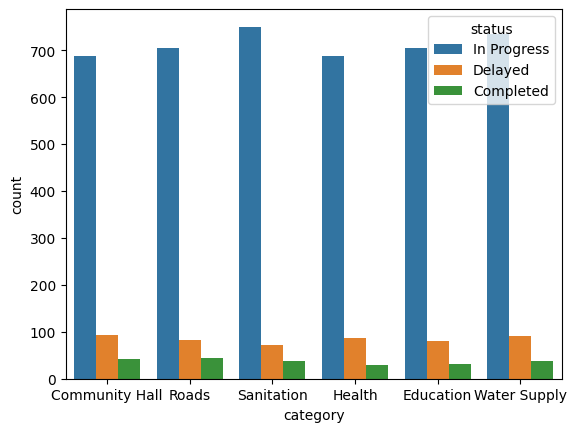

In [55]:
sns.countplot(x = 'category',hue = 'status',data = df)

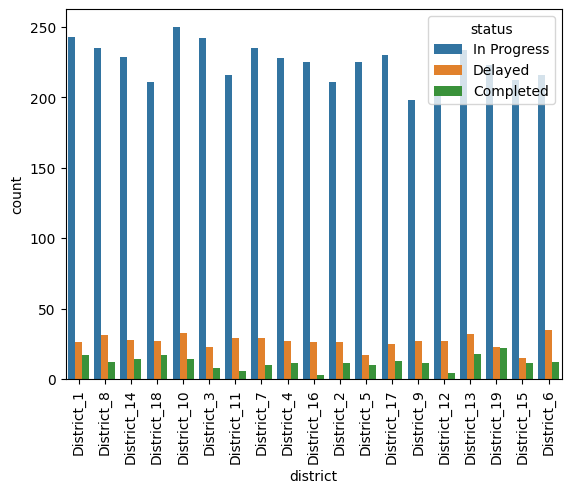

In [56]:
sns.countplot(x = 'district',hue = 'status',data = df)
plt.xticks(rotation = 90)
plt.show()

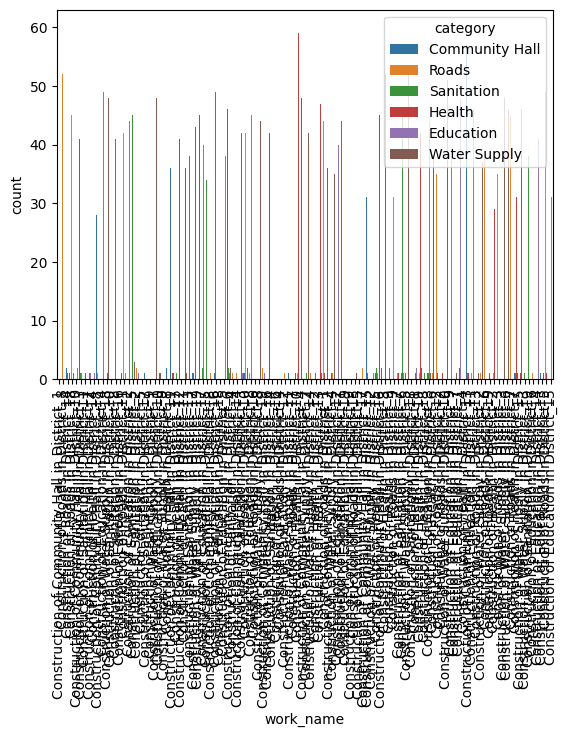

In [57]:
sns.countplot(x = 'work_name',hue = 'category',data = df)
plt.xticks(rotation = 90)
plt.show()

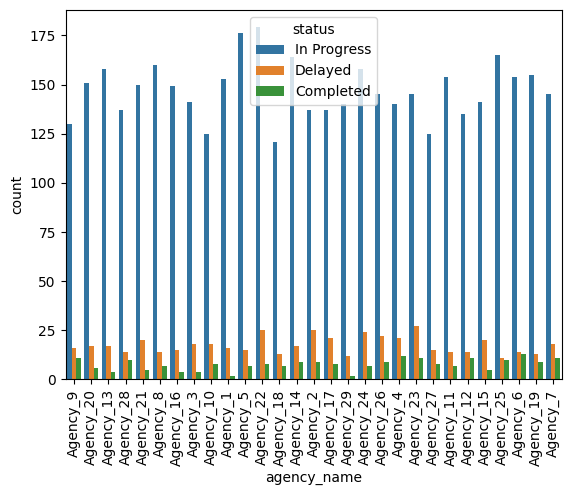

In [58]:
sns.countplot(x = 'agency_name',hue = 'status',data = df)
plt.xticks(rotation = 90)
plt.show()

11 . Bivariate Analysis (Numerical VS Categorical)

<Axes: xlabel='category', ylabel='expenditure'>

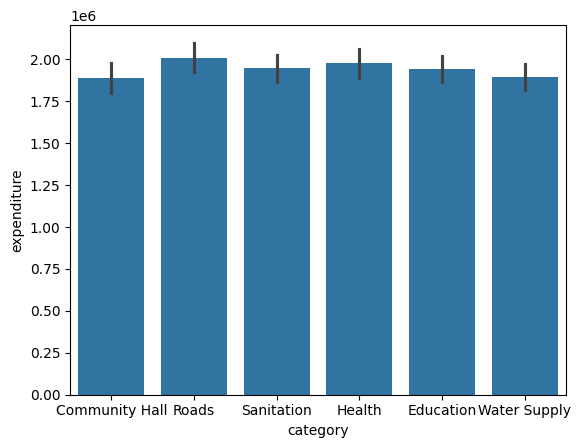

In [59]:
sns.barplot(x = 'category',y='expenditure',data = df)

<Axes: xlabel='category', ylabel='progress_percentage'>

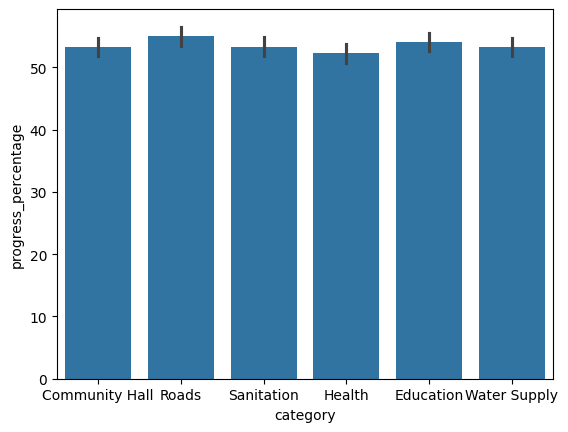

In [60]:
sns.barplot(x = 'category',y = 'progress_percentage',data = df)

<Axes: xlabel='category', ylabel='estimated_cost'>

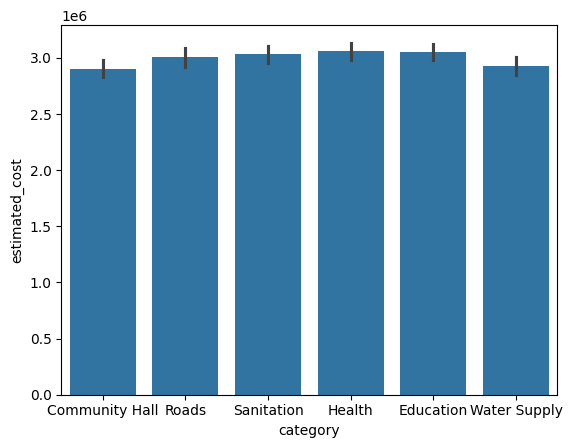

In [61]:
sns.barplot(x = 'category',y = 'estimated_cost',data = df)

<Axes: xlabel='status', ylabel='progress_percentage'>

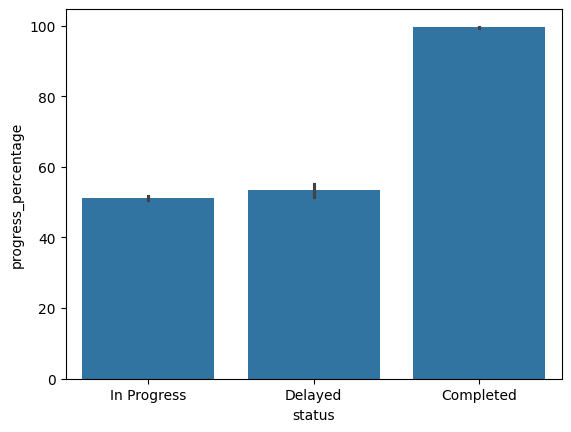

In [62]:
sns.barplot(x = 'status',y = 'progress_percentage',data = df)

<Axes: xlabel='status', ylabel='estimated_cost'>

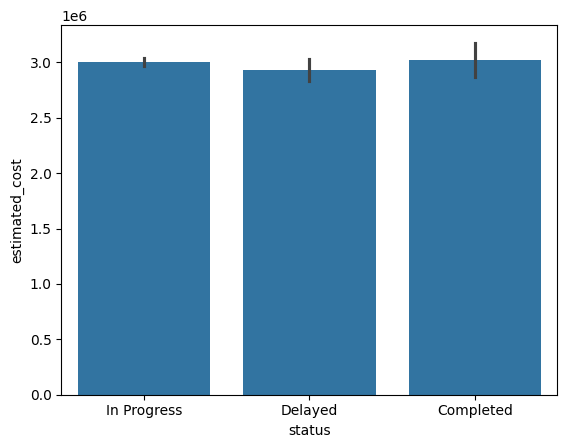

In [63]:
sns.barplot(x = 'status',y = 'estimated_cost',data = df)

<Axes: xlabel='state', ylabel='expenditure'>

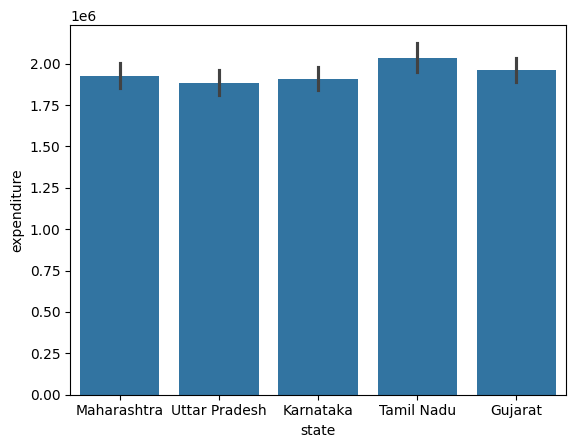

In [64]:
sns.barplot(x = 'state',y = 'expenditure',data = df)

12 . OUTLIERS

<Axes: xlabel='estimated_cost'>

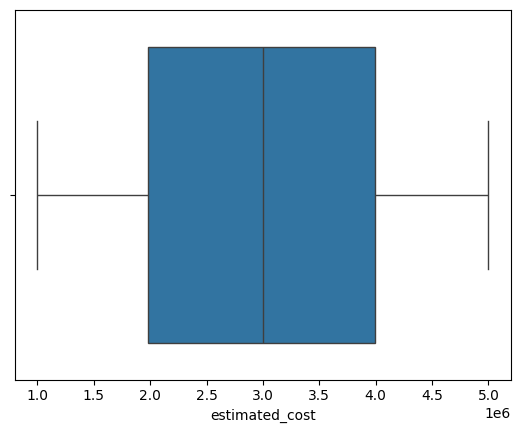

In [65]:
sns.boxplot(x = df['estimated_cost'])

<Axes: xlabel='sanctioned_amount'>

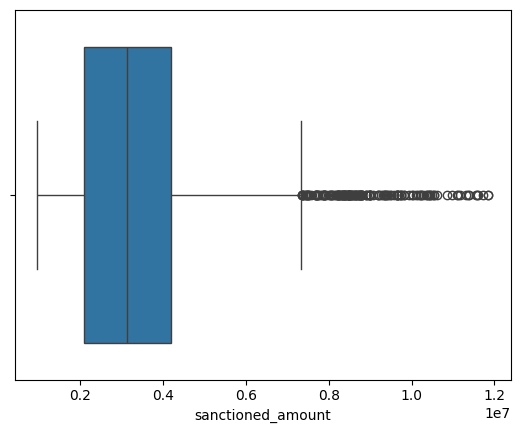

In [66]:
sns.boxplot(x = df['sanctioned_amount'])

<Axes: xlabel='released_amount'>

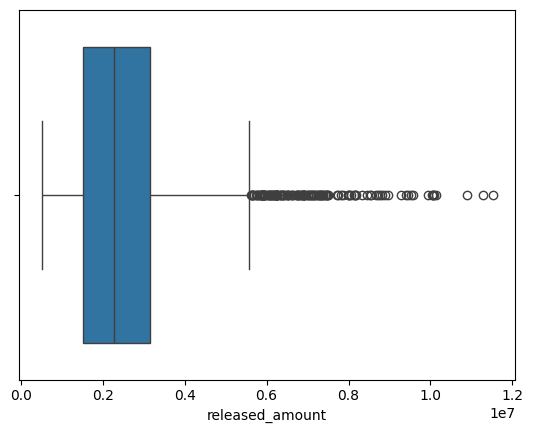

In [67]:
sns.boxplot(x = df['released_amount'])

<Axes: xlabel='expenditure'>

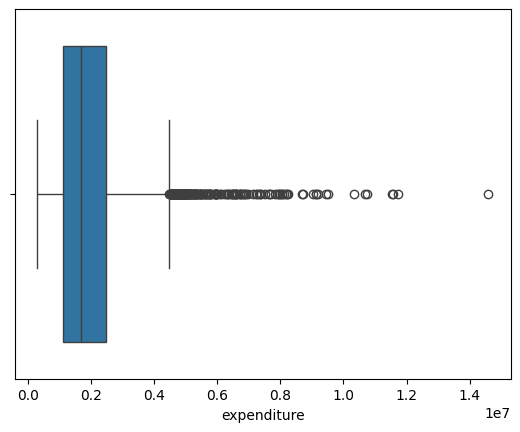

In [68]:
sns.boxplot(x = df['expenditure'])

<Axes: xlabel='progress_percentage'>

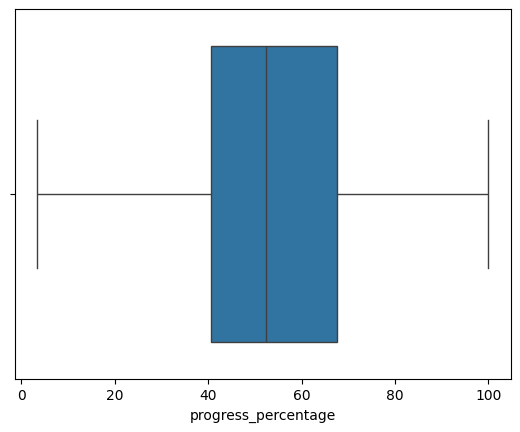

In [69]:
sns.boxplot(x = df['progress_percentage'])

13 . Correlaton / Heatmap

In [70]:
df.corr(numeric_only = True)

,estimated_cost,sanctioned_amount,released_amount,expenditure,progress_percentage,latitude,longitude,is_cost_anomaly,is_exp_anomaly,is_progress_anomaly,is_delay,is_duplicate
estimated_cost,1.000000,0.781038,0.720322,0.609881,0.006024,-0.012924,-0.025179,0.002531,-0.001766,-0.015017,-0.017550,0.007860
sanctioned_amount,0.781038,1.000000,0.917774,0.792791,0.004152,-0.006174,-0.023749,0.558583,0.013459,0.001047,-0.001235,0.016938
released_amount,0.720322,0.917774,1.000000,0.862840,0.170968,-0.012497,-0.015949,0.504521,0.010717,-0.011387,-0.001335,0.011390
expenditure,0.609881,0.792791,0.862840,1.000000,0.418457,-0.003986,-0.008697,0.448080,0.366505,-0.017267,0.005779,0.024156
progress_percentage,0.006024,0.004152,0.170968,0.418457,1.000000,-0.008735,0.022674,-0.002839,0.457630,-0.604890,-0.002832,0.004452
latitude,-0.012924,-0.006174,-0.012497,-0.003986,-0.008735,1.000000,0.011837,0.006636,0.009528,0.011273,-0.001005,-0.021483
longitude,-0.025179,-0.023749,-0.015949,-0.008697,0.022674,0.011837,1.000000,-0.004639,0.016462,-0.003028,0.007021,-0.008493
is_cost_anomaly,0.002531,0.558583,0.504521,0.448080,-0.002839,0.006636,-0.004639,1.000000,0.014032,0.013036,0.017089,0.025672
is_exp_anomaly,-0.001766,0.013459,0.010717,0.366505,0.457630,0.009528,0.016462,0.014032,1.000000,0.005143,0.002693,0.016449
is_progress_anomaly,-0.015017,0.001047,-0.011387,-0.017267,-0.604890,0.011273,-0.003028,0.013036,0.005143,1.000000,0.021774,-0.004897


<Axes: >

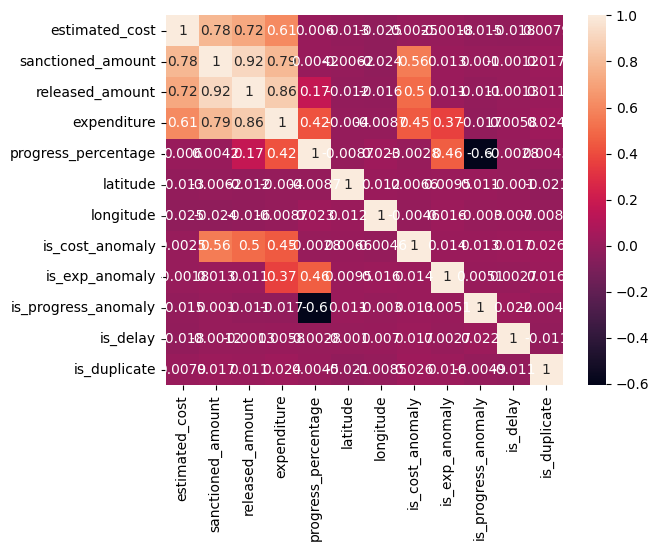

In [71]:
sns.heatmap(df.corr(numeric_only = True),annot = True)

# Feature Engineering 

1 . Feature Selection 

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   project_id           5000 non-null   object 
 1   work_name            5000 non-null   object 
 2   category             5000 non-null   object 
 3   mp_name              5000 non-null   object 
 4   state                5000 non-null   object 
 5   district             5000 non-null   object 
 6   agency_name          5000 non-null   object 
 7   sanction_date        5000 non-null   object 
 8   expected_completion  5000 non-null   object 
 9   estimated_cost       5000 non-null   float64
 10  sanctioned_amount    5000 non-null   float64
 11  released_amount      5000 non-null   float64
 12  expenditure          5000 non-null   float64
 13  progress_percentage  5000 non-null   float64
 14  latitude             5000 non-null   float64
 15  longitude            5000 non-null   f

In [73]:
df = df.drop(columns = 'project_id',axis = 1)

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   work_name            5000 non-null   object 
 1   category             5000 non-null   object 
 2   mp_name              5000 non-null   object 
 3   state                5000 non-null   object 
 4   district             5000 non-null   object 
 5   agency_name          5000 non-null   object 
 6   sanction_date        5000 non-null   object 
 7   expected_completion  5000 non-null   object 
 8   estimated_cost       5000 non-null   float64
 9   sanctioned_amount    5000 non-null   float64
 10  released_amount      5000 non-null   float64
 11  expenditure          5000 non-null   float64
 12  progress_percentage  5000 non-null   float64
 13  latitude             5000 non-null   float64
 14  longitude            5000 non-null   float64
 15  status               5000 non-null   o

In [75]:
df.head()

,work_name,category,mp_name,state,district,agency_name,sanction_date,expected_completion,estimated_cost,sanctioned_amount,...,expenditure,progress_percentage,latitude,longitude,status,is_cost_anomaly,is_exp_anomaly,is_progress_anomaly,is_delay,is_duplicate
0,Construction of Community Hall in District_1,Community Hall,MP_48,Maharashtra,District_1,Agency_9,2023-10-07,2024-04-26,2498160.48,2610756.14,...,1739533.45,62.05,12.523841,69.684425,In Progress,False,False,False,False,True
1,Construction of Roads in District_8,Roads,MP_33,Uttar Pradesh,District_8,Agency_20,2023-10-07,2024-07-20,4464704.58,9380857.82,...,4080008.07,47.58,32.140837,74.157834,In Progress,True,False,False,False,False
2,Construction of Roads in District_14,Roads,MP_22,Uttar Pradesh,District_14,Agency_9,2023-02-17,2023-11-21,1727299.87,1672614.33,...,802943.03,47.35,16.445645,85.743734,Delayed,False,False,False,True,False
3,Construction of Roads in District_18,Roads,MP_8,Karnataka,District_18,Agency_13,2023-07-05,2024-05-27,1557975.44,2792117.35,...,1345244.10,50.93,13.790540,82.912799,In Progress,True,False,False,False,False
4,Construction of Community Hall in District_10,Community Hall,MP_6,Uttar Pradesh,District_10,Agency_28,2023-11-22,2024-08-21,3369658.28,3216827.56,...,1491206.67,42.32,35.517681,96.003329,In Progress,False,False,False,False,False


2 . Handle Date And Time 

In [76]:
df['sanction_date'] = pd.to_datetime(df['sanction_date'])

In [77]:
df['sanction_years'] = pd.to_datetime(df['sanction_date']).dt.year

In [78]:
df['sanction_months'] = pd.to_datetime(df['sanction_date']).dt.month

In [79]:
df.head()

,work_name,category,mp_name,state,district,agency_name,sanction_date,expected_completion,estimated_cost,sanctioned_amount,...,latitude,longitude,status,is_cost_anomaly,is_exp_anomaly,is_progress_anomaly,is_delay,is_duplicate,sanction_years,sanction_months
0,Construction of Community Hall in District_1,Community Hall,MP_48,Maharashtra,District_1,Agency_9,2023-10-07,2024-04-26,2498160.48,2610756.14,...,12.523841,69.684425,In Progress,False,False,False,False,True,2023,10
1,Construction of Roads in District_8,Roads,MP_33,Uttar Pradesh,District_8,Agency_20,2023-10-07,2024-07-20,4464704.58,9380857.82,...,32.140837,74.157834,In Progress,True,False,False,False,False,2023,10
2,Construction of Roads in District_14,Roads,MP_22,Uttar Pradesh,District_14,Agency_9,2023-02-17,2023-11-21,1727299.87,1672614.33,...,16.445645,85.743734,Delayed,False,False,False,True,False,2023,2
3,Construction of Roads in District_18,Roads,MP_8,Karnataka,District_18,Agency_13,2023-07-05,2024-05-27,1557975.44,2792117.35,...,13.790540,82.912799,In Progress,True,False,False,False,False,2023,7
4,Construction of Community Hall in District_10,Community Hall,MP_6,Uttar Pradesh,District_10,Agency_28,2023-11-22,2024-08-21,3369658.28,3216827.56,...,35.517681,96.003329,In Progress,False,False,False,False,False,2023,11


In [80]:
df = df.drop(columns = 'sanction_date',axis = 1)

In [81]:
df['expected_completion'] = pd.to_datetime(df['expected_completion'])

In [82]:
df['expected_year'] = pd.to_datetime(df['expected_completion']).dt.year
df['expected_month'] = pd.to_datetime(df['expected_completion']).dt.month

In [83]:
df = df.drop(columns = 'expected_completion',axis = 1)

In [84]:
df.head()

,work_name,category,mp_name,state,district,agency_name,estimated_cost,sanctioned_amount,released_amount,expenditure,...,status,is_cost_anomaly,is_exp_anomaly,is_progress_anomaly,is_delay,is_duplicate,sanction_years,sanction_months,expected_year,expected_month
0,Construction of Community Hall in District_1,Community Hall,MP_48,Maharashtra,District_1,Agency_9,2498160.48,2610756.14,2260906.91,1739533.45,...,In Progress,False,False,False,False,True,2023,10,2024,4
1,Construction of Roads in District_8,Roads,MP_33,Uttar Pradesh,District_8,Agency_20,4464704.58,9380857.82,8011593.00,4080008.07,...,In Progress,True,False,False,False,False,2023,10,2024,7
2,Construction of Roads in District_14,Roads,MP_22,Uttar Pradesh,District_14,Agency_9,1727299.87,1672614.33,1090747.14,802943.03,...,Delayed,False,False,False,True,False,2023,2,2023,11
3,Construction of Roads in District_18,Roads,MP_8,Karnataka,District_18,Agency_13,1557975.44,2792117.35,1907521.31,1345244.10,...,In Progress,True,False,False,False,False,2023,7,2024,5
4,Construction of Community Hall in District_10,Community Hall,MP_6,Uttar Pradesh,District_10,Agency_28,3369658.28,3216827.56,2585597.29,1491206.67,...,In Progress,False,False,False,False,False,2023,11,2024,8


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   work_name            5000 non-null   object 
 1   category             5000 non-null   object 
 2   mp_name              5000 non-null   object 
 3   state                5000 non-null   object 
 4   district             5000 non-null   object 
 5   agency_name          5000 non-null   object 
 6   estimated_cost       5000 non-null   float64
 7   sanctioned_amount    5000 non-null   float64
 8   released_amount      5000 non-null   float64
 9   expenditure          5000 non-null   float64
 10  progress_percentage  5000 non-null   float64
 11  latitude             5000 non-null   float64
 12  longitude            5000 non-null   float64
 13  status               5000 non-null   object 
 14  is_cost_anomaly      5000 non-null   bool   
 15  is_exp_anomaly       5000 non-null   b

# Target Columns

In [86]:
target = [
    "is_cost_anomaly",
    "is_exp_anomaly",
    "is_progress_anomaly",
    "is_delay",
    "is_duplicate"
    ]

# Model -> 1 . Cost Anomaly Model

In [91]:
X = df.drop(columns = target,axis = 1)
y = df['is_cost_anomaly']

# Train test Split

In [92]:
from sklearn.model_selection import train_test_split

In [93]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

In [96]:
X_train.shape

(4000, 18)

In [97]:
y_train.shape

(4000,)

# Column Transformer

In [98]:
num_cols = X_train.select_dtypes(include=["int","float"]).columns

In [99]:
cat_cols = X_train.select_dtypes(include="object").columns

In [100]:
print("Numerical Columns are",num_cols)

Numerical Columns are Index(['estimated_cost', 'sanctioned_amount', 'released_amount', 'expenditure',
       'progress_percentage', 'latitude', 'longitude', 'sanction_years',
       'sanction_months', 'expected_year', 'expected_month'],
      dtype='object')


In [101]:
print("categorical columns are ",cat_cols)

categorical columns are  Index(['work_name', 'category', 'mp_name', 'state', 'district', 'agency_name',
       'status'],
      dtype='object')


In [102]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler

In [103]:
from sklearn.compose import ColumnTransformer

In [107]:
preprocessor = ColumnTransformer([
    ("num",StandardScaler(),num_cols),
    ("cat",OneHotEncoder(handle_unknown="ignore"),cat_cols)
])
remainder='passthrough'

# Logistic Regression Algorithm with Pipeline 

In [111]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [113]:
lr_pipe = Pipeline([
    ("preprocessing",preprocessor),
    ("model",LogisticRegression(max_iter = 2000,random_state = 42))
])

In [114]:
lr_pipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[bool](2,)","[False, True]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](18,)","['work_name','category','mp_name',...,'sanction_months','expected_year', 'expected_month']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,18
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rema

In [115]:
# Prediction

In [116]:
y_pred = lr_pipe.predict(X_test)

In [117]:
y_pred

array([False, False, False, False,  True, False, False, False, False,
       False,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False,  True, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False,  True, False, False,  True, False, False,
       False, False, False, False, False, False, False,  True, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False,  True, False, False,
       False, False, False, False, False, False, False, False, False,
        True, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

In [119]:
y_proba = lr_pipe.predict_proba(X_test)[:,1]

In [120]:
y_proba

array([2.24859707e-03, 2.74721827e-03, 3.19007445e-03, 4.74970067e-03,
       9.99993713e-01, 4.31087029e-04, 3.85736717e-03, 9.18526675e-04,
       1.29241820e-03, 4.47154199e-03, 1.00000000e+00, 1.20072679e-03,
       8.24981523e-05, 2.25735013e-03, 1.51120570e-03, 1.01867693e-02,
       2.07955012e-05, 6.06496248e-04, 7.10876570e-03, 3.73869216e-04,
       2.62565146e-04, 7.15379070e-04, 1.21308910e-03, 5.91779855e-04,
       9.21932278e-03, 1.99451192e-03, 9.35756808e-03, 4.02195662e-02,
       1.29847221e-03, 5.70385059e-04, 3.05686625e-03, 6.37401476e-04,
       1.68812509e-03, 1.56773603e-03, 9.99999963e-01, 2.22873238e-03,
       5.39002590e-03, 7.41848692e-03, 7.78854402e-03, 3.37773130e-04,
       8.40531534e-03, 2.50181498e-03, 2.80206057e-04, 1.79655547e-03,
       2.82124402e-03, 4.21108424e-03, 3.05633098e-02, 2.33531630e-03,
       9.99999938e-01, 3.28017437e-03, 4.06025705e-03, 9.95357517e-01,
       1.62492755e-03, 6.52429502e-04, 1.22071989e-03, 1.85384248e-03,
      

In [121]:
# Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,roc_